In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
 
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Losing MNIST Dataset
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

X_all = mnist.data.astype(np.float32) / 255.0   # shape (70000, 784), normalise [0,1]
y_all = mnist.target.astype(int)

# Taking only 10k samples, for better t-SNE
# Use 10 000 samples (balanced across classes) for speed
np.random.seed(42)
idx = np.concatenate([np.where(y_all == d)[0][:1000] for d in range(10)])
X, y = X_all[idx], y_all[idx]     # (10000, 784)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


INPUT_DIM   = 784   # 28×28
LATENT_DIM  = 4
COMPRESSION = INPUT_DIM / LATENT_DIM    # 196×

print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Input dim={INPUT_DIM}, Latent dim={LATENT_DIM}")
print(f"  Compression ratio = {INPUT_DIM}/{LATENT_DIM} = {COMPRESSION:.0f}×\n")

  Train: (8000, 784), Test: (2000, 784)
  Input dim=784, Latent dim=4
  Compression ratio = 784/4 = 196×



In [4]:
print("Training PCA …")
pca = PCA(n_components=LATENT_DIM, random_state=42)
pca.fit(X_train)
 
Z_pca_train = pca.transform(X_train)            # (8000, 4)
Z_pca_test  = pca.transform(X_test)             # (2000, 4)
 
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"  Variance explained: {var_explained:.2f}%\n")

Training PCA …
  Variance explained: 28.58%



In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64,  LATENT_DIM)  
        )
    def forward(self,x):
            return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()  # pixel values in [0,1]
        )
    def forward(self, z):
        return self.net(z)        
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [6]:
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 50
BATCH_SIZE = 256
LR         = 1e-3
 
Xt = torch.tensor(X_train)
Xv = torch.tensor(X_test)
 
train_loader = DataLoader(TensorDataset(Xt), batch_size=BATCH_SIZE, shuffle=True)
 
model     = AutoEncoder().to(DEVICE)
criterion = nn.BCELoss()                         # pixel-wise binary cross-entropy
optimizer = optim.Adam(model.parameters(), lr=LR)
 
print("Training AutoEncoder …")
train_losses = []
 
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for (xb,) in train_loader:
        xb = xb.to(DEVICE)
        recon = model(xb)
        loss  = criterion(recon, xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  BCE={avg:.4f}")

Training AutoEncoder …
  Epoch  10/50  BCE=0.1929
  Epoch  20/50  BCE=0.1723
  Epoch  30/50  BCE=0.1644
  Epoch  40/50  BCE=0.1589
  Epoch  50/50  BCE=0.1549


In [7]:
model.eval()
with torch.no_grad():
    Z_ae_train = model.encoder(Xt.to(DEVICE)).cpu().numpy()   # (8000, 4)
    Z_ae_test  = model.encoder(Xv.to(DEVICE)).cpu().numpy()   # (2000, 4)
print()

In [8]:
print("Running t-SNE …")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=42, n_jobs=-1)
 
Z_pca_2d = tsne.fit_transform(Z_pca_test)
Z_ae_2d  = tsne.fit_transform(Z_ae_test)

Running t-SNE …


In [9]:
recon_idx = np.concatenate(
    [np.where(y_test == d)[0][:2] for d in range(10)]
)
X_orig  = X_test[recon_idx]                      # (20, 784) originals
labels  = y_test[recon_idx]
 
# PCA reconstruct
X_pca_recon = np.clip(pca.inverse_transform(Z_pca_test[recon_idx]), 0, 1)
 
# AE reconstruct
with torch.no_grad():
    X_ae_recon = model(
        torch.tensor(X_orig).to(DEVICE)
    ).cpu().numpy()
 
# Reconstruction MSE
mse_pca = np.mean((X_test - np.clip(pca.inverse_transform(Z_pca_test), 0, 1))**2)
mse_ae  = np.mean((X_test - model(Xv.to(DEVICE)).cpu().detach().numpy())**2)

In [10]:
CMAP = plt.cm.get_cmap("tab10", 10)

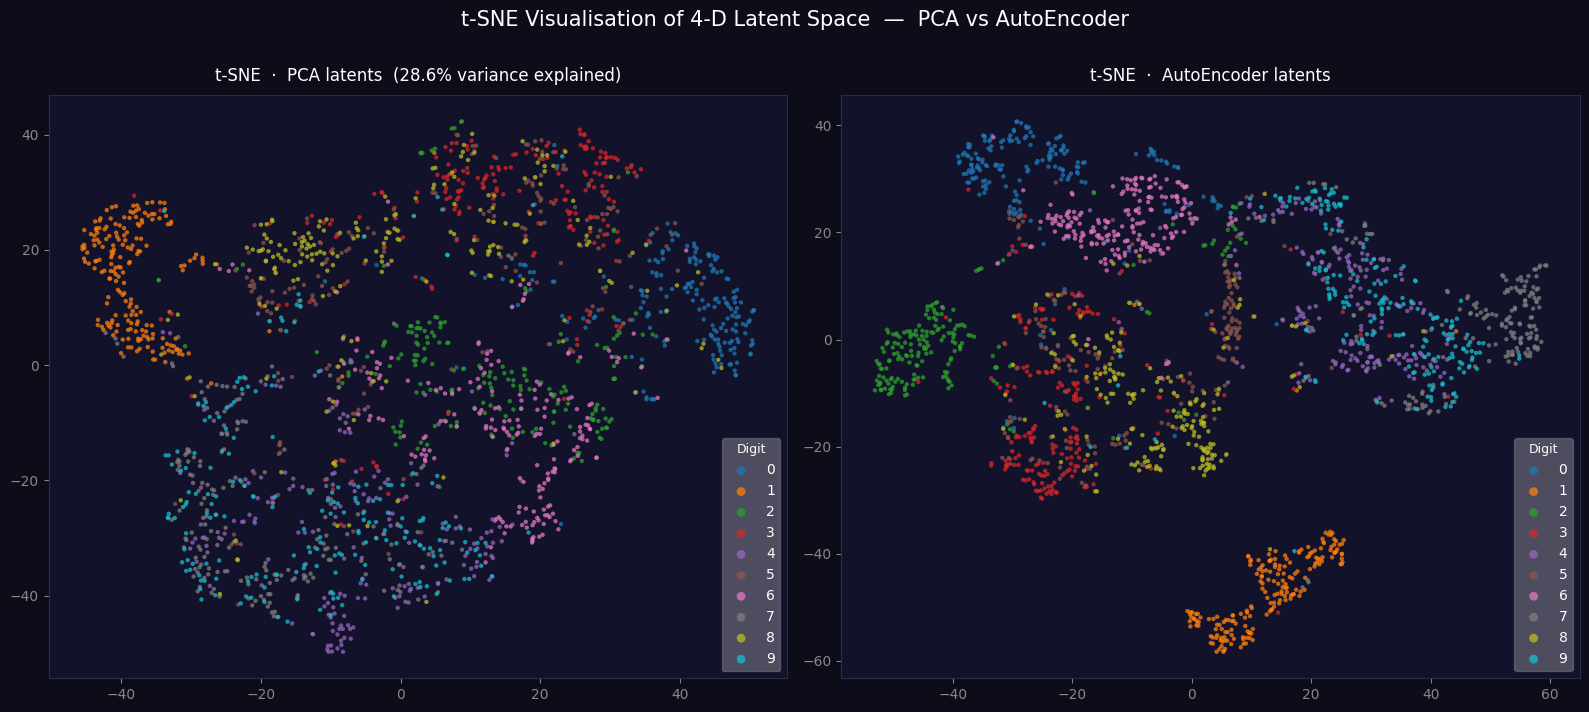

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0d0d1a")
titles = [f"PCA latents  ({var_explained:.1f}% variance explained)",
          "AutoEncoder latents"]
 
for ax, Z2d, title in zip(axes, [Z_pca_2d, Z_ae_2d], titles):
    ax.set_facecolor("#12122a")
    for d in range(10):
        m = y_test == d
        ax.scatter(Z2d[m, 0], Z2d[m, 1], c=[CMAP(d)], label=str(d),
                   s=10, alpha=0.75, edgecolors="none")
    ax.set_title(f"t-SNE  ·  {title}", color="white", fontsize=12, pad=10)
    ax.tick_params(colors="#888")
    for sp in ax.spines.values(): sp.set_edgecolor("#2a2a4a")
    leg = ax.legend(title="Digit", loc="lower right", markerscale=2,
                    framealpha=0.25, labelcolor="white", title_fontsize=9)
    leg.get_title().set_color("white")
 
plt.suptitle("t-SNE Visualisation of 4-D Latent Space  —  PCA vs AutoEncoder",
             color="white", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Saved → reconstruction_comparison.png


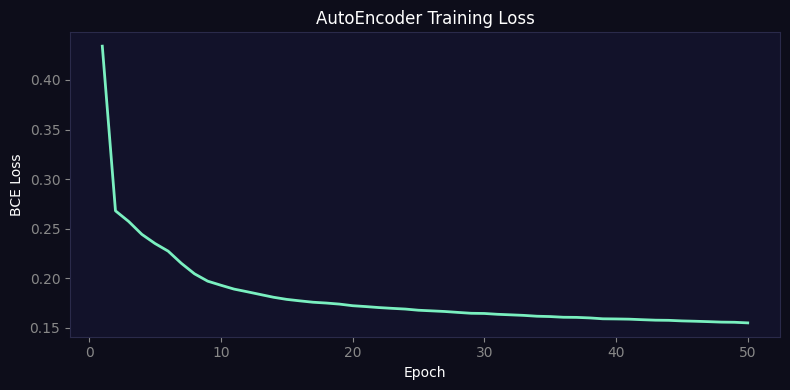

In [12]:
n = 20
fig = plt.figure(figsize=(n * 1.2, 5))
fig.patch.set_facecolor("#0d0d1a")
gs  = gridspec.GridSpec(3, n, hspace=0.08, wspace=0.04)
 
rows = [("Original",    X_orig,      "#aaddff"),
        ("PCA recon",   X_pca_recon, "#ffcc88"),
        ("AE  recon",   X_ae_recon,  "#aaffcc")]
 
for ri, (row_lbl, data, col) in enumerate(rows):
    for ci in range(n):
        ax = fig.add_subplot(gs[ri, ci])
        ax.imshow(data[ci].reshape(28, 28), cmap="gray",
                  vmin=0, vmax=1, interpolation="bilinear")
        ax.axis("off")
        if ci == 0:
            ax.set_ylabel(row_lbl, color=col, fontsize=9,
                          rotation=90, labelpad=4, va="center")
        if ri == 0:
            ax.set_title(str(labels[ci]), color="white",
                         fontsize=8, pad=2)
 
plt.suptitle(
    f"Reconstruction of 20 MNIST Samples  ·  Compression {COMPRESSION:.0f}×  "
    f"(784 → 4)\n"
    f"PCA MSE={mse_pca:.4f}   |   AE MSE={mse_ae:.4f}",
    color="white", fontsize=12, y=1.03)
plt.savefig("reconstruction_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d1a")
plt.close()
print("Saved → reconstruction_comparison.png")
 
 
# AE Training loss
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("#0d0d1a")
ax.set_facecolor("#12122a")
ax.plot(range(1, EPOCHS + 1), train_losses, color="#7af0c0", lw=2)
ax.set(xlabel="Epoch", ylabel="BCE Loss",
       title="AutoEncoder Training Loss")
ax.tick_params(colors="#888"); ax.title.set_color("white")
ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
for sp in ax.spines.values(): sp.set_edgecolor("#2a2a4a")
plt.tight_layout()
plt.show()

In [13]:
print("Results Summary")
print(f"  Input dimension        : {INPUT_DIM}  (28×28 pixels)")
print(f"  Latent dimension       : {LATENT_DIM}")
print(f"  Compression ratio      : {COMPRESSION:.0f}×  (784 → 4)")
print(f"")
print(f"  PCA  variance explained: {var_explained:.2f}%")
print(f"  PCA  MSE (test set)    : {mse_pca:.6f}")
print(f"")
print(f"  AE   final BCE loss    : {train_losses[-1]:.4f}")
print(f"  AE   MSE  (test set)   : {mse_ae:.6f}")

Results Summary
  Input dimension        : 784  (28×28 pixels)
  Latent dimension       : 4
  Compression ratio      : 196×  (784 → 4)

  PCA  variance explained: 28.58%
  PCA  MSE (test set)    : 0.047357

  AE   final BCE loss    : 0.1549
  AE   MSE  (test set)   : 0.031940
